# Customer Analytics: Online Retail II

Este notebook só **lê e mostra** o que o banco calculou (views do schema `analise`).
Nenhuma regra é recalculada aqui: limpeza, RFM, churn, coortes e CLV estão em SQL
versionado (`db/migracoes`) e testados (`tests/`). As decisões e os números estão em
[`docs/DECISOES.md`](../docs/DECISOES.md).

Pré-requisitos: `python -m varejo.carga` e `python -m varejo.processar`.

In [1]:
import pandas as pd
from IPython.display import display

from varejo import graficos
from varejo.banco import engine
from varejo.config import RAIZ_PROJETO, carregar_config_banco

motor = engine(carregar_config_banco())
IMG = RAIZ_PROJETO / "docs" / "img"
IMG.mkdir(parents=True, exist_ok=True)


def ler(consulta: str) -> pd.DataFrame:
    return pd.read_sql(consulta, motor)


def salvar(fig, nome: str) -> None:
    fig.savefig(IMG / f"{nome}.png")


pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

## 0. Qualidade dos dados

Antes de qualquer número, as 16 checagens do schema `dq`. Todas precisam estar ok.

In [2]:
dq = ler("SELECT camada, verificacao, esperado, obtido, ok FROM dq.resultado ORDER BY camada, verificacao")
assert dq["ok"].all(), "há checagem de qualidade falhando"
dq

,camada,verificacao,esperado,obtido,ok
0,analise,analise_churn_validado_nos_dois_cortes,2,2,True
1,analise,analise_clientes_com_compra,5852,5852,True
2,analise,analise_clv_preenchido,0,0,True
3,analise,analise_coortes_somam_clientes,5852,5852,True
4,analise,analise_pedidos_somam_o_limpo,19057002.628,19057002.628,True
5,analise,analise_quintis_r_e_m,<= 1.10,1.03,True
6,analise,analise_receita_liquida_bate,16413300.877,16413300.877,True
7,bruto,bruto_formatos,0,0,True
8,bruto,bruto_linhas_da_ultima_carga,1067371,1067371,True
9,limpo,limpo_anomalias_novas,0,0,True


## 1. Visão geral

Receita de produto por mês, separando o que tem cliente identificado do que não tem
(essa parte não entra nas análises de cliente, mas é receita real).

,£
venda_produto_com_cliente,"17,124,941.00"
venda_produto_sem_cliente,"2,576,013.46"
cancelamento_produto,"-719,692.94"
receita_produto_liquida,"18,981,261.52"
frete_taxas_e_ajustes,"75,741.11"


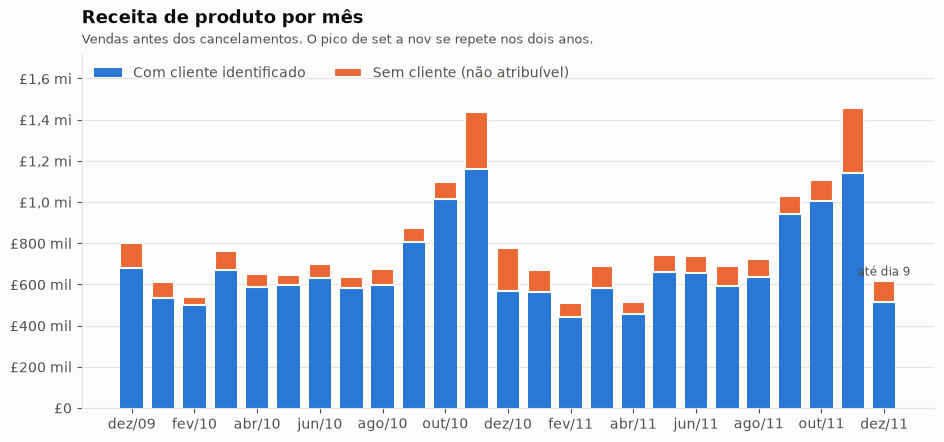

In [3]:
receita = ler("SELECT * FROM analise.vw_receita_mes ORDER BY mes")
fig = graficos.receita_mensal(receita)
salvar(fig, "receita_mensal")
totais = receita[["venda_produto_com_cliente", "venda_produto_sem_cliente",
                  "cancelamento_produto", "receita_produto_liquida", "frete_taxas_e_ajustes"]].sum()
totais.to_frame("£")

**Leitura:** a sazonalidade é forte e se repete: setembro a novembro concentram o
ano (nov/2010 e nov/2011 passam de £1,4 mi, contra £0,5 a £0,7 mi nos meses comuns).
Dez/2011 vai só até o dia 9. Cerca de 13% da receita de produto vem de vendas sem
cliente identificado.

## 2. Quem são os melhores clientes? (RFM)

Notas de 1 a 5 por `percent_rank` (empates com a mesma nota) e segmento pelo mapa R x F.

,segmento,clientes,pct_clientes,pct_receita,recencia_media,frequencia_media,ticket_medio,atacado
0,Campeões,1380,0.24,0.69,20.00,16.20,407.85,165
1,Leais,1025,0.18,0.14,87.00,6.00,361.88,108
2,Potenciais leais,442,0.08,0.02,19.00,2.60,349.25,45
3,Novos,72,0.01,0.00,11.00,1.00,339.10,14
4,Promissores,163,0.03,0.00,38.00,1.00,330.35,16
5,Precisam de atenção,425,0.07,0.01,107.00,1.40,380.55,66
6,Não pode perder,66,0.01,0.03,330.00,17.10,360.54,8
7,Em risco,647,0.11,0.06,362.00,4.30,328.40,49
8,Hibernando,673,0.12,0.02,314.00,1.40,315.18,50
9,Perdidos,959,0.16,0.02,552.00,1.30,324.85,86


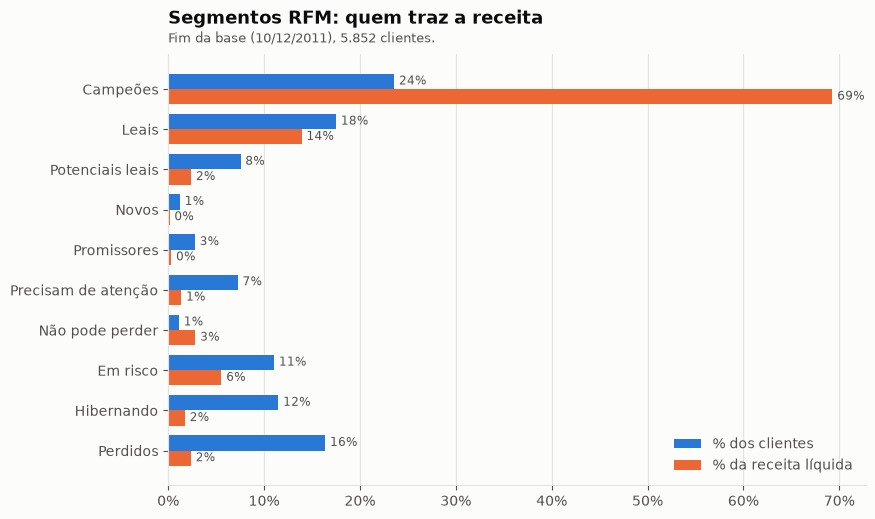

In [4]:
resumo = ler("SELECT * FROM analise.vw_segmento_resumo ORDER BY ordem")
fig = graficos.segmentos(resumo)
salvar(fig, "segmentos")
resumo[["segmento", "clientes", "pct_clientes", "pct_receita", "recencia_media",
        "frequencia_media", "ticket_medio", "atacado"]]

**Leitura:** os Campeões são 24% dos clientes e fazem 69% da receita líquida.
"Não pode perder" é pequeno (66 clientes), mas tem frequência média de 17 compras: é
a lista de contato pessoal do CRM.

In [5]:
clientes = ler("SELECT perfil, count(*) AS clientes, sum(receita_liquida) AS receita FROM analise.vw_cliente GROUP BY perfil")
clientes["pct_receita"] = clientes["receita"] / clientes["receita"].sum()
clientes

,perfil,clientes,receita,pct_receita
0,Varejo,5245,"10,171,390.34",0.62
1,Atacado,607,"6,241,910.54",0.38


## 3. Quem está indo embora? (churn)

Regra: mais de X dias sem comprar. Validada em dois cortes, só com o passado: o "real"
é não ter comprado nos 6 meses seguintes.

,corte,dias,marcados,precisao,recall,f1,acuracia,escolhido
0,2011-06-10,30,3907,0.56,0.93,0.70,0.62,False
1,2011-06-10,60,3375,0.61,0.87,0.71,0.67,False
2,2011-06-10,90,2971,0.64,0.80,0.71,0.69,True
3,2011-06-10,120,2666,0.67,0.75,0.71,0.70,False
4,2011-06-10,150,2441,0.68,0.70,0.69,0.70,False
5,2011-06-10,180,2306,0.69,0.67,0.68,0.70,False
6,2011-06-10,240,1350,0.78,0.44,0.56,0.67,False
7,2011-06-10,365,621,0.85,0.22,0.35,0.61,False
8,2010-12-10,30,2718,0.64,0.76,0.70,0.64,False
9,2010-12-10,60,1912,0.69,0.57,0.63,0.63,False


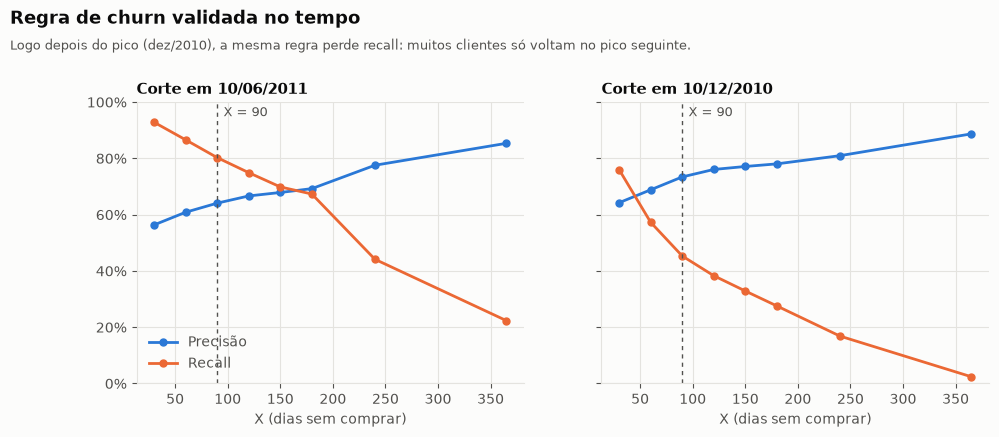

In [6]:
validacao = ler("SELECT * FROM analise.churn_validacao ORDER BY corte DESC, dias")
x = int(ler("SELECT valor FROM analise.parametro WHERE nome = 'churn_dias'").iloc[0, 0])
fig = graficos.validacao_churn(validacao, x)
salvar(fig, "validacao_churn")
validacao[["corte", "dias", "marcados", "precisao", "recall", "f1", "acuracia", "escolhido"]]

**Leitura:** no corte de junho, X = 90 tem o melhor F1 entre 90, 120 e 180 (0,71):
dos marcados, 64% de fato não voltaram, e a regra pegou 80% dos que não voltaram. Em
dezembro, logo depois do pico, a mesma regra perde recall (45%): muitos clientes só
voltam no pico seguinte. A marcação do fim da base (também em dezembro) é, portanto,
conservadora.

In [7]:
ler("""SELECT segmento, count(*) FILTER (WHERE em_churn) AS em_churn,
           round(sum(receita_12m) FILTER (WHERE em_churn)) AS receita_12m_em_risco
    FROM analise.vw_cliente GROUP BY segmento, segmento_ordem ORDER BY segmento_ordem""")

,segmento,em_churn,receita_12m_em_risco
0,Campeões,0,NaN
1,Leais,402,"401,070.00"
2,Potenciais leais,0,NaN
3,Novos,0,NaN
4,Promissores,0,NaN
5,Precisam de atenção,220,"94,255.00"
6,Não pode perder,66,"42,907.00"
7,Em risco,647,"152,013.00"
8,Hibernando,673,"145,824.00"
9,Perdidos,959,-948.00


## 4. A retenção melhora ou piora? (coortes)

,ativos,tamanho,retencao
meses_desde,,,
1,982,4682,0.21
3,901,4273,0.21
6,730,3957,0.18
12,606,3288,0.18


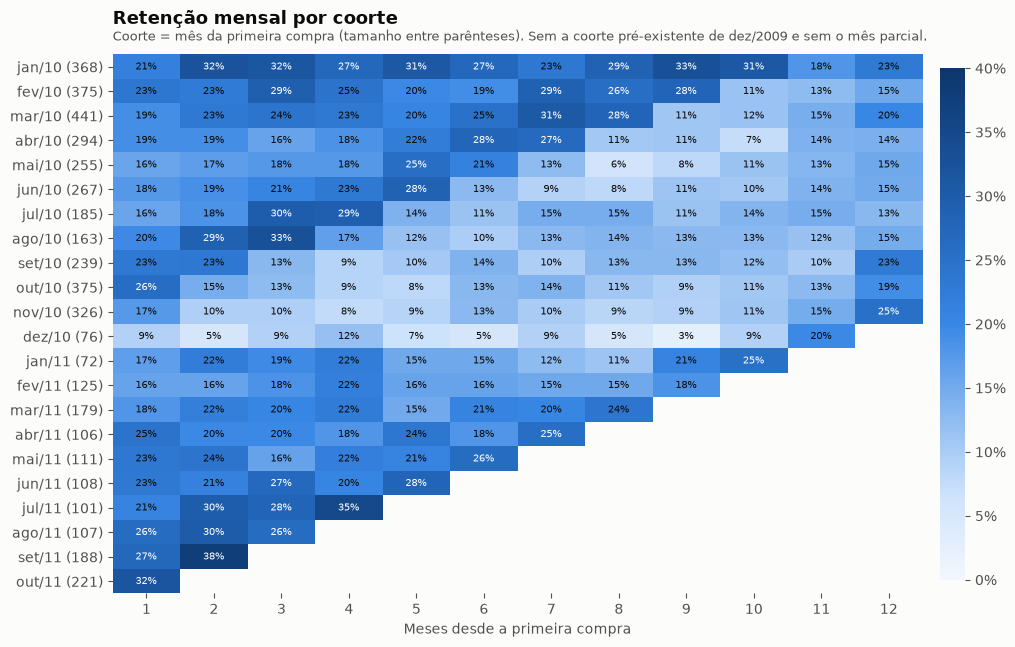

In [8]:
coortes = ler("SELECT * FROM analise.coorte_retencao")
fig = graficos.heatmap_coortes(coortes)
salvar(fig, "coortes")
sem_pre = coortes[~coortes["pre_existente"] & ~coortes["mes_parcial"]]
media = (sem_pre[sem_pre["meses_desde"].isin([1, 3, 6, 12])]
         .groupby("meses_desde")[["ativos", "tamanho"]].sum())
media["retencao"] = media["ativos"] / media["tamanho"]
media

**Leitura:** a retenção é estável, em torno de 21% no mês 1 e 18% no mês 6, sem
piora entre 2010 e 2011. O que caiu foi a entrada de clientes novos (set-nov: 940 em
2010, 600 em 2011). A diagonal mais escura nas coortes de 2010 é o pico de set-nov do
ano seguinte.

## 5. Quanto vale cada cliente? (CLV)

CLV previsto = p_ativo(segmento) x ticket médio x compras por mês x meses. Validado
com a previsão feita em 10/06/2011 contra a receita real até 10/12/2011.

,modelo,clientes,total_previsto,total_real,erro_total_pct,erro_medio_abs,captura_top20
0,ingenuo,4944,"3,005,615.24","4,243,517.70",-29.17,547.34,0.87
1,previsto,4944,"4,263,961.12","4,243,517.70",0.48,604.36,0.88


,previsto,ingenuo,real
segmento,,,
Campeões,"2,582,372.83","2,293,333.02","3,117,946.63"
Leais,"570,310.42","324,395.37","428,285.55"
Potenciais leais,"247,920.23","208,322.74","187,207.08"
Novos,"57,119.96","26,838.00","34,976.24"
Promissores,"124,907.37","72,712.92","62,488.43"
Precisam de atenção,"124,847.03","81,395.14","60,247.93"
Não pode perder,"37,926.88",0.00,"12,704.36"
Em risco,"211,513.67",-102.75,"136,733.17"
Hibernando,"187,951.70",-463.59,"140,322.45"


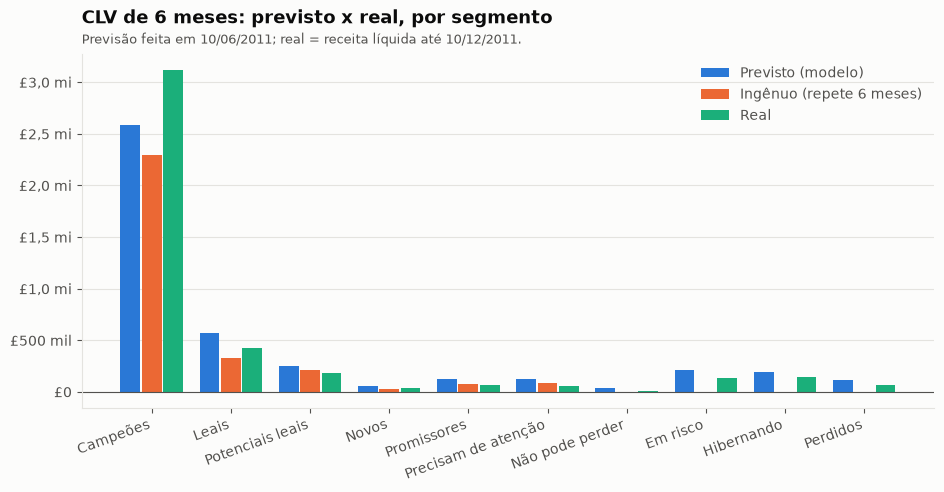

In [9]:
resumo_clv = ler("SELECT * FROM analise.clv_validacao")
display(resumo_clv)
validacao_clv = ler("SELECT * FROM analise.clv_validacao_cliente")
ordem = resumo.sort_values("ordem")["segmento"].tolist()
fig = graficos.clv_previsto_vs_real(validacao_clv, ordem)
salvar(fig, "clv_validacao")
validacao_clv.groupby("segmento")[["previsto", "ingenuo", "real"]].sum().reindex(ordem)

**Leitura:** o modelo erra o total em +0,5%, e o ingênuo ("repete os 6 meses
anteriores") erra em -29%, porque não enxerga o pico de fim de ano. Na ordenação os
dois empatam (os 20% maiores previstos capturam 88% do que um top 20% perfeito
capturaria). O ingênuo ganha no erro médio por cliente. Detalhes em DECISOES D24.

In [10]:
ler("""SELECT round(sum(clv_previsto_6m)) AS clv_6m_total,
           round(avg(clv_previsto_6m)) AS media,
           round(percentile_cont(0.5) WITHIN GROUP (ORDER BY clv_previsto_6m)) AS mediana
    FROM analise.cliente""")

,clv_6m_total,media,mediana
0,"3,809,240.00",651.00,222.00
